In [ ]:
# Week 2: Exploratory Data Analysis (EDA)
Instead of raw data, we strictly utilize our pristine, clean dataset from Week 1 to identify 
the statistical driving factors behind hotel cancellations.


In [1]:
# Day 1:IMporting Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional corporate styling
sns.set_theme(style="whitegrid", palette="muted")


In [5]:
# Load our strictly cleaned dataset from Week 1!
df = pd.read_csv('cleaned_hotel_data_week1.csv')
print(f"Pristine Data Loaded! Dimensions: {df.shape}")

print("\n--- Day 1: Baseline Cancellation Rate ---")
print(df['is_canceled'].value_counts(normalize=True) * 100)


Pristine Data Loaded! Dimensions: (119388, 32)

--- Day 1: Baseline Cancellation Rate ---
is_canceled
False    62.958589
True     37.041411
Name: proportion, dtype: float64


In [ ]:
## Day 2: Univariate Analysis (Booking Demographics)
We need to visually determine which booking channels (Online Travel Agents, Direct, Corporate) 
drive the highest volume of cancellations.


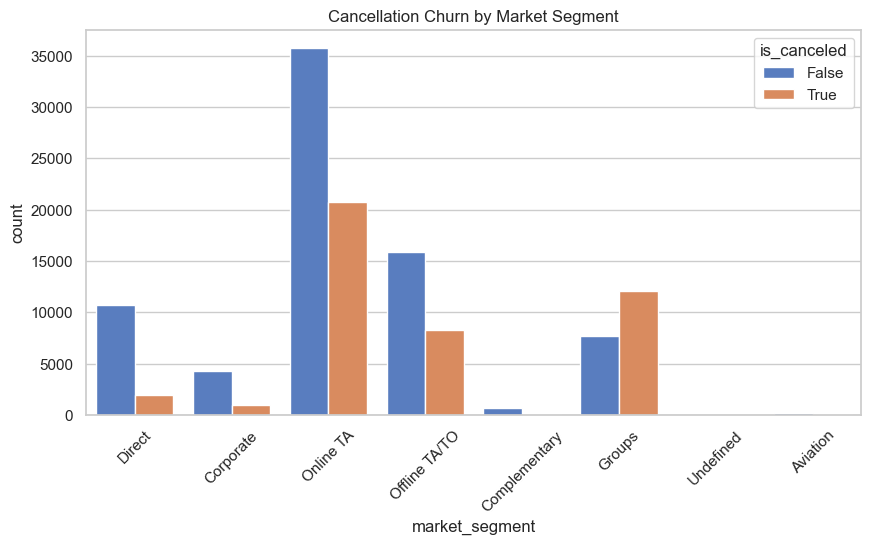

In [3]:
# Initialize the figure size and plot the churn by market segment
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='market_segment', hue='is_canceled')
# Add formatting so the chart is professional and readable
plt.title("Cancellation Churn by Market Segment")
plt.xticks(rotation=45)
plt.show()


In [ ]:
## Day 3: Financial Impact Analysis (ADR)
We will analyze the Average Daily Rate (ADR) to determine if premium pricing correlates with a higher attrition rate.
We cap the Y-axis at $400 to remove visual distortion from luxury suites.


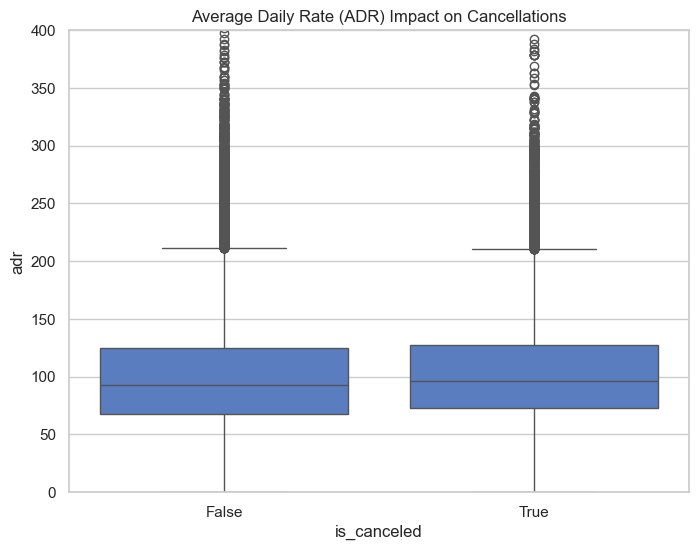

In [9]:
# Do expensive rooms cancel more often?
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_canceled', y='adr')

plt.title("Average Daily Rate (ADR) Impact on Cancellations")

# Limit y-axis to standard prices so the chart isn't squished
plt.ylim(0, 400) 
plt.show()


In [ ]:
## Day 4: Correlation Heatmap
To prepare for Machine Learning, we must identify which numerical features have the highest mathematical correlation 
with the target variable (`is_canceled`).


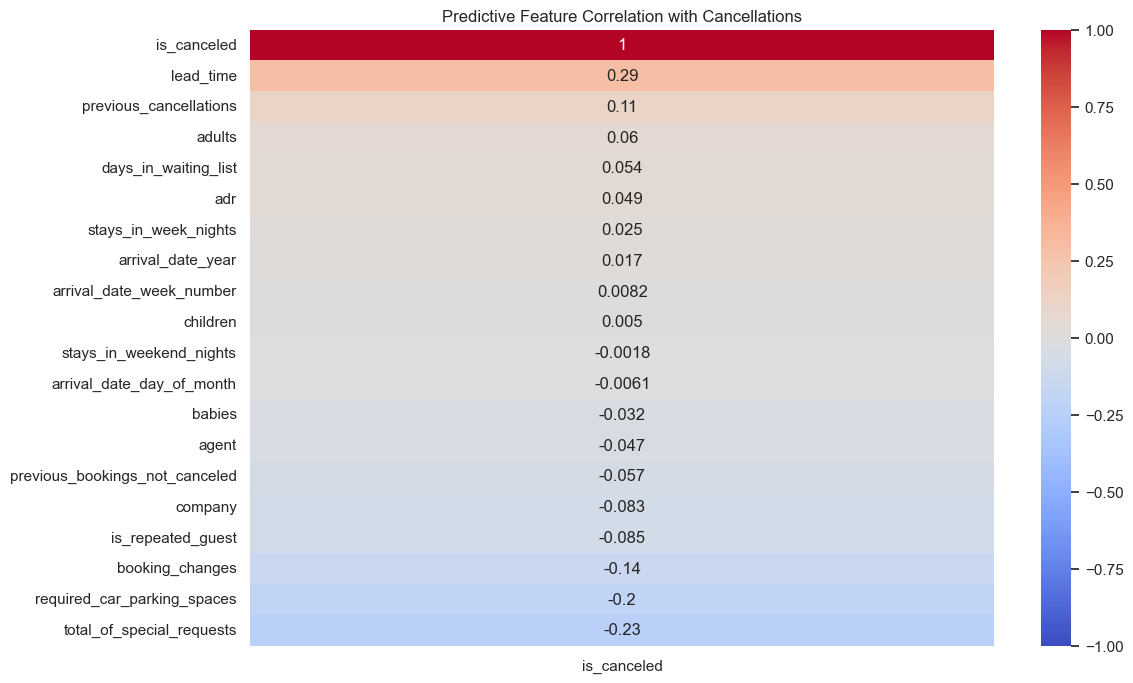

In [4]:

numerical_df = df.select_dtypes(include=['int64', 'float64', 'bool'])

plt.figure(figsize=(12, 8))

# here i want to Calculate the mathematical correlation
correlation_matrix = numerical_df.corr()

# Plot a heatmap 'is_canceled'
sns.heatmap(correlation_matrix[['is_canceled']].sort_values(by='is_canceled', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Predictive Feature Correlation with Cancellations")
plt.show()
